#### ***Setup and Data Loading***
---

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Settings for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Load cleaned data
cleaned_file = Path(
    "C:/Users/Laude/ComProg_Lab/EDS_4764_LaudeV2/data/dataset_cleaned.csv"
)
df = pd.read_csv(cleaned_file)
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df["HOUR"] = df["DATETIME"].dt.hour

# Parameters
IRRADIATION_THRESHOLD = 0.3

# Split data
cloud_df = df[df["CLOUD_CONDITION"] == "Cloud-Affected"]
clear_df = df[df["CLOUD_CONDITION"] == "Clear-Sky"]

print(f"Loaded {len(df)} records:")
print(f"    Cloud-Affected: {len(cloud_df)} rows")
print(f"    Clear-Sky: {len(clear_df)} rows")

Loaded 621 records:
    Cloud-Affected: 126 rows
    Clear-Sky: 495 rows


---
#### ***Boxplot***

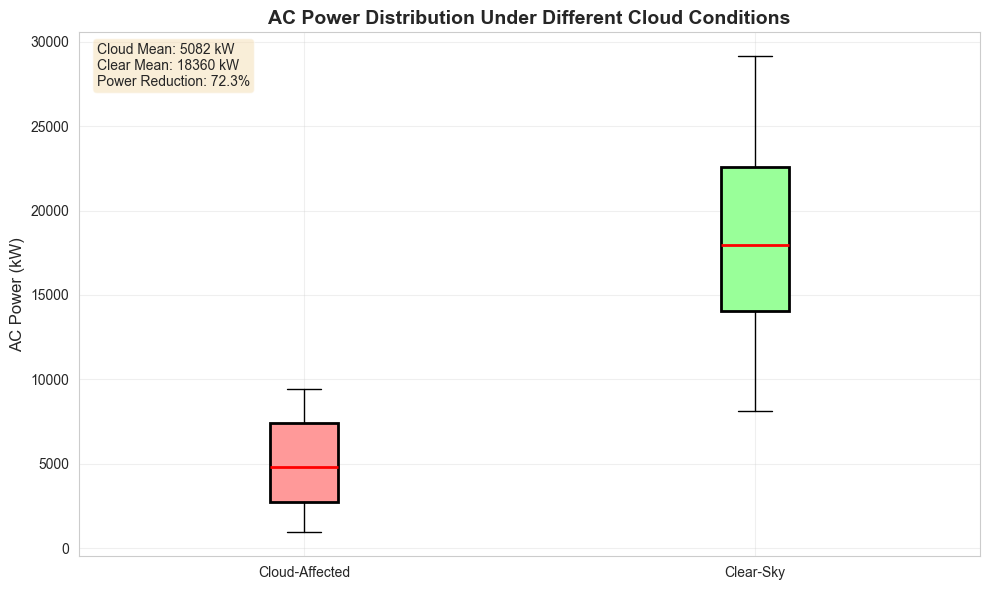

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

cloud_data = cloud_df["AC_POWER"].values
clear_data = clear_df["AC_POWER"].values

bp = ax.boxplot(
    [cloud_data, clear_data],
    labels=["Cloud-Affected", "Clear-Sky"],
    patch_artist=True,
    boxprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="red"),
)
bp["boxes"][0].set_facecolor("#FF9999")
bp["boxes"][1].set_facecolor("#99FF99")

ax.set_title(
    "AC Power Distribution Under Different Cloud Conditions",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("AC Power (kW)", fontsize=12)
ax.grid(True, alpha=0.3)

# Add statistics annotation
ax.text(
    0.02,
    0.98,
    f"Cloud Mean: {np.mean(cloud_data):.0f} kW\n"
    f"Clear Mean: {np.mean(clear_data):.0f} kW\n"
    f"Power Reduction: {((np.mean(clear_data)-np.mean(cloud_data))/np.mean(clear_data)*100):.1f}%",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

---
#### ***Scatter Plot***

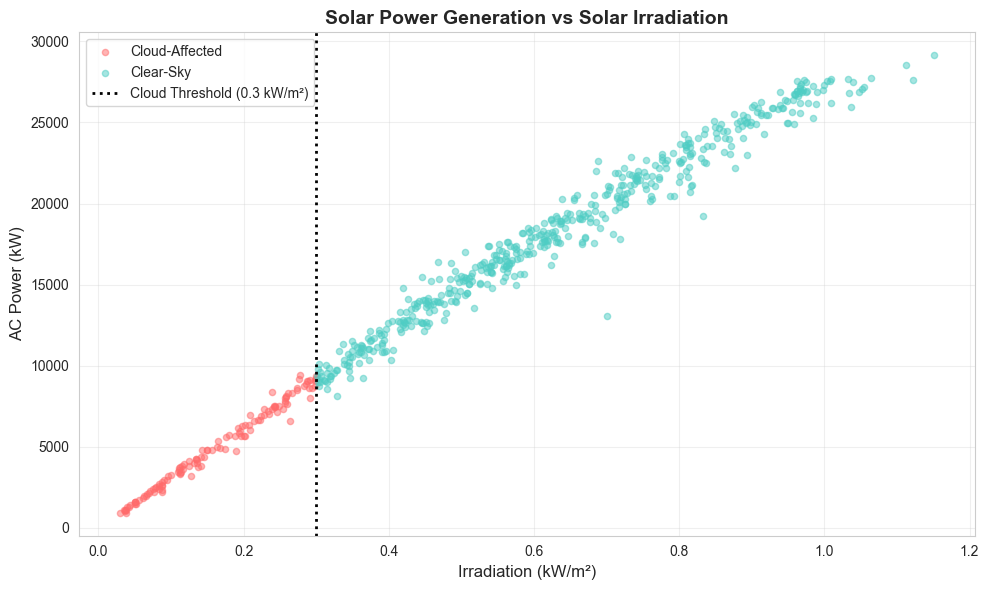

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Cloud-Affected": "#FF6B6B", "Clear-Sky": "#4ECDC4"}

for condition in ["Cloud-Affected", "Clear-Sky"]:
    subset = df[df["CLOUD_CONDITION"] == condition]
    ax.scatter(
        subset["IRRADIATION"],
        subset["AC_POWER"],
        alpha=0.5,
        s=20,
        label=condition,
        color=colors[condition],
    )

# Add threshold line
ax.axvline(
    x=IRRADIATION_THRESHOLD,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Cloud Threshold ({IRRADIATION_THRESHOLD} kW/m²)",
)

ax.set_xlabel("Irradiation (kW/m²)", fontsize=12)
ax.set_ylabel("AC Power (kW)", fontsize=12)
ax.set_title(
    "Solar Power Generation vs Solar Irradiation",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
#### ***Correlation Heatmap***

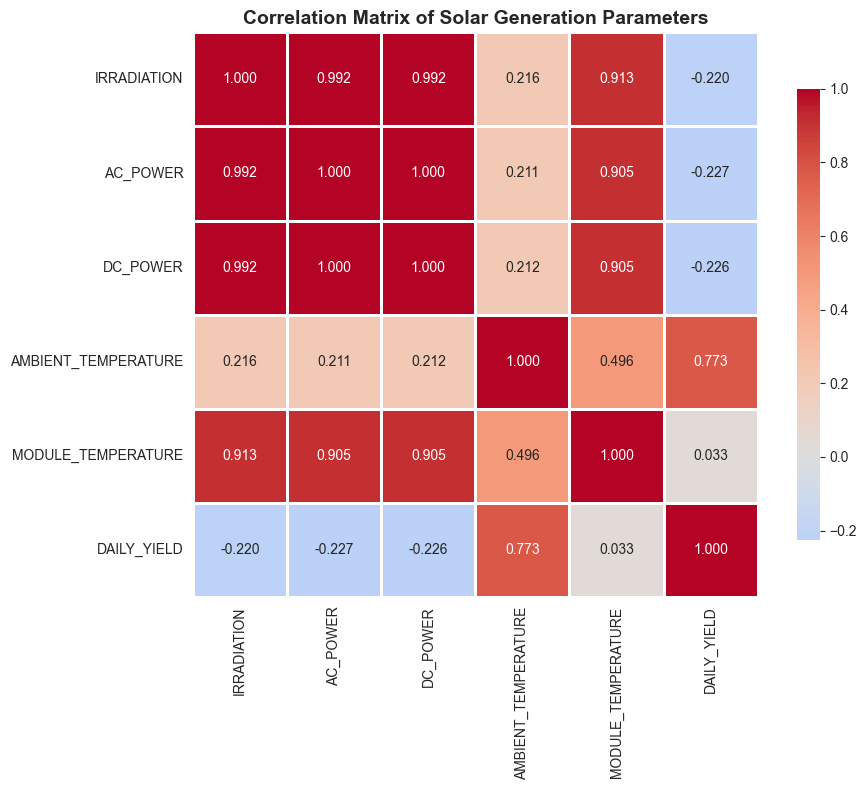

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

# Select numerical columns for correlation
corr_cols = [
    "IRRADIATION",
    "AC_POWER",
    "DC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "DAILY_YIELD",
]
corr_matrix = df[[c for c in corr_cols if c in df.columns]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
    annot_kws={"size": 10},
)

ax.set_title(
    "Correlation Matrix of Solar Generation Parameters",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

---
#### ***Bar Chart***

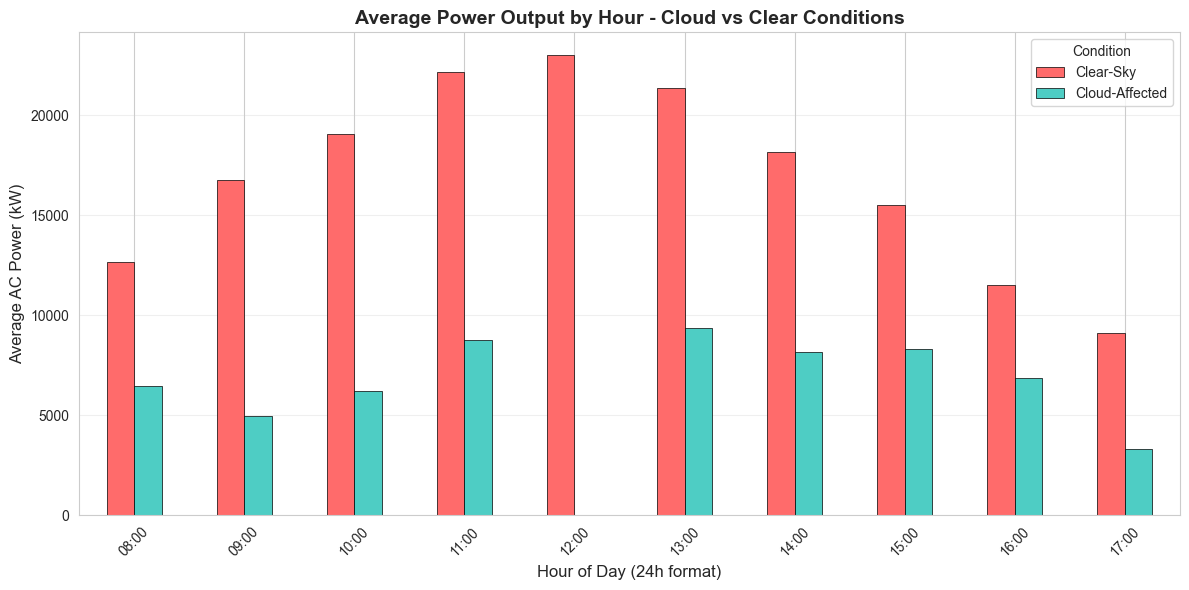

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

hourly_stats = df.groupby(["HOUR", "CLOUD_CONDITION"])["AC_POWER"].mean().unstack()

hourly_stats.plot(
    kind="bar",
    ax=ax,
    color=["#FF6B6B", "#4ECDC4"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("Hour of Day (24h format)", fontsize=12)
ax.set_ylabel("Average AC Power (kW)", fontsize=12)
ax.set_title(
    "Average Power Output by Hour - Cloud vs Clear Conditions",
    fontsize=14,
    fontweight="bold",
)
ax.legend(title="Condition", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticklabels([f"{h:02d}:00" for h in hourly_stats.index], rotation=45)

plt.tight_layout()
plt.show()

---
#### ***Feature Importance***

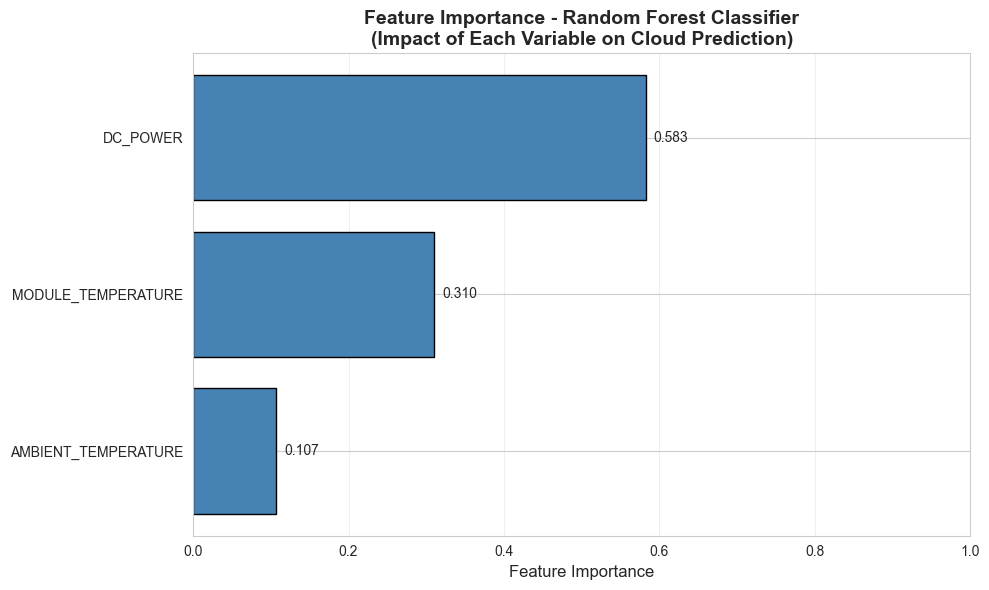

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["MODULE_TEMPERATURE", "AMBIENT_TEMPERATURE", "DC_POWER"]
X = df[feature_cols]
y = (df["IRRADIATION"] < IRRADIATION_THRESHOLD).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
pos = np.arange(len(sorted_idx)) + 0.5

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    pos,
    importances[sorted_idx],
    align="center",
    color="steelblue",
    edgecolor="black",
)

for idx, bar in zip(sorted_idx, bars):
    ax.text(
        importances[idx] + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{importances[idx]:.3f}",
        va="center",
        fontsize=10,
    )

ax.set_yticks(pos)
ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_xlim(0, 1.0)
ax.set_title(
    "Feature Importance - Random Forest Classifier\n(Impact of Each Variable on Cloud Prediction)",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

---
#### ***Freeze Frame - Animation 1***

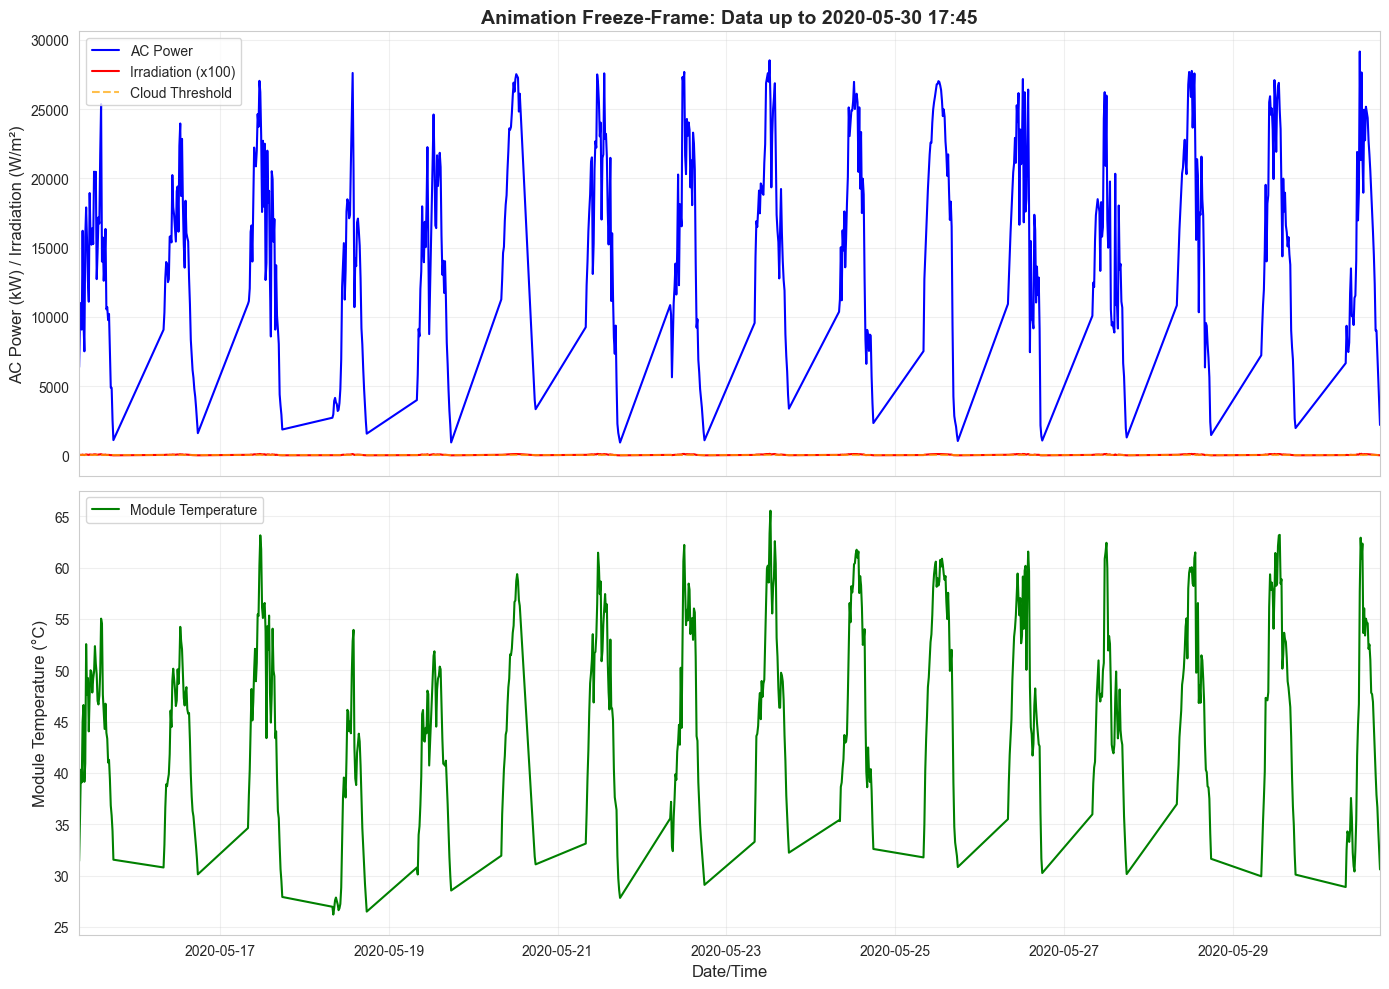

In [31]:
df_sorted = df.sort_values("DATETIME")
timestamps = df_sorted["DATETIME"].unique()
timestamps = np.sort(timestamps)

# Freeze at last timestamp
ts = timestamps[-1]

# Data up to freeze timestamp
current_data = df_sorted[df_sorted["DATETIME"] <= ts]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# AC Power (blue)
ax1.plot(
    current_data["DATETIME"],
    current_data["AC_POWER"],
    "b-",
    linewidth=1.5,
    label="AC Power",
)

# Irradiation x100 (red)
ax1.plot(
    current_data["DATETIME"],
    current_data["IRRADIATION"] * 100,
    "r-",
    linewidth=1.5,
    label="Irradiation (x100)",
)

# Cloud Threshold (orange dashed)
ax1.axhline(
    y=IRRADIATION_THRESHOLD * 100,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Cloud Threshold",
)

# Module Temperature (green)
ax2.plot(
    current_data["DATETIME"],
    current_data["MODULE_TEMPERATURE"],
    "g-",
    linewidth=1.5,
    label="Module Temperature",
)

# NO RED SCATTER DOTS - this is the key difference!

ax1.set_ylabel("AC Power (kW) / Irradiation (W/m²)", fontsize=12)
ax2.set_ylabel("Module Temperature (°C)", fontsize=12)
ax2.set_xlabel("Date/Time", fontsize=12)
ax1.set_title(
    f"Animation Freeze-Frame: Data up to {pd.to_datetime(ts).strftime('%Y-%m-%d %H:%M')}",
    fontsize=14,
    fontweight="bold",
)
ax1.legend(loc="upper left", fontsize=10)
ax2.legend(loc="upper left", fontsize=10)
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
ax1.set_xlim(timestamps[0], timestamps[-1])

plt.tight_layout()
plt.show()

---
#### ***Freeze Frame - Animation 2***

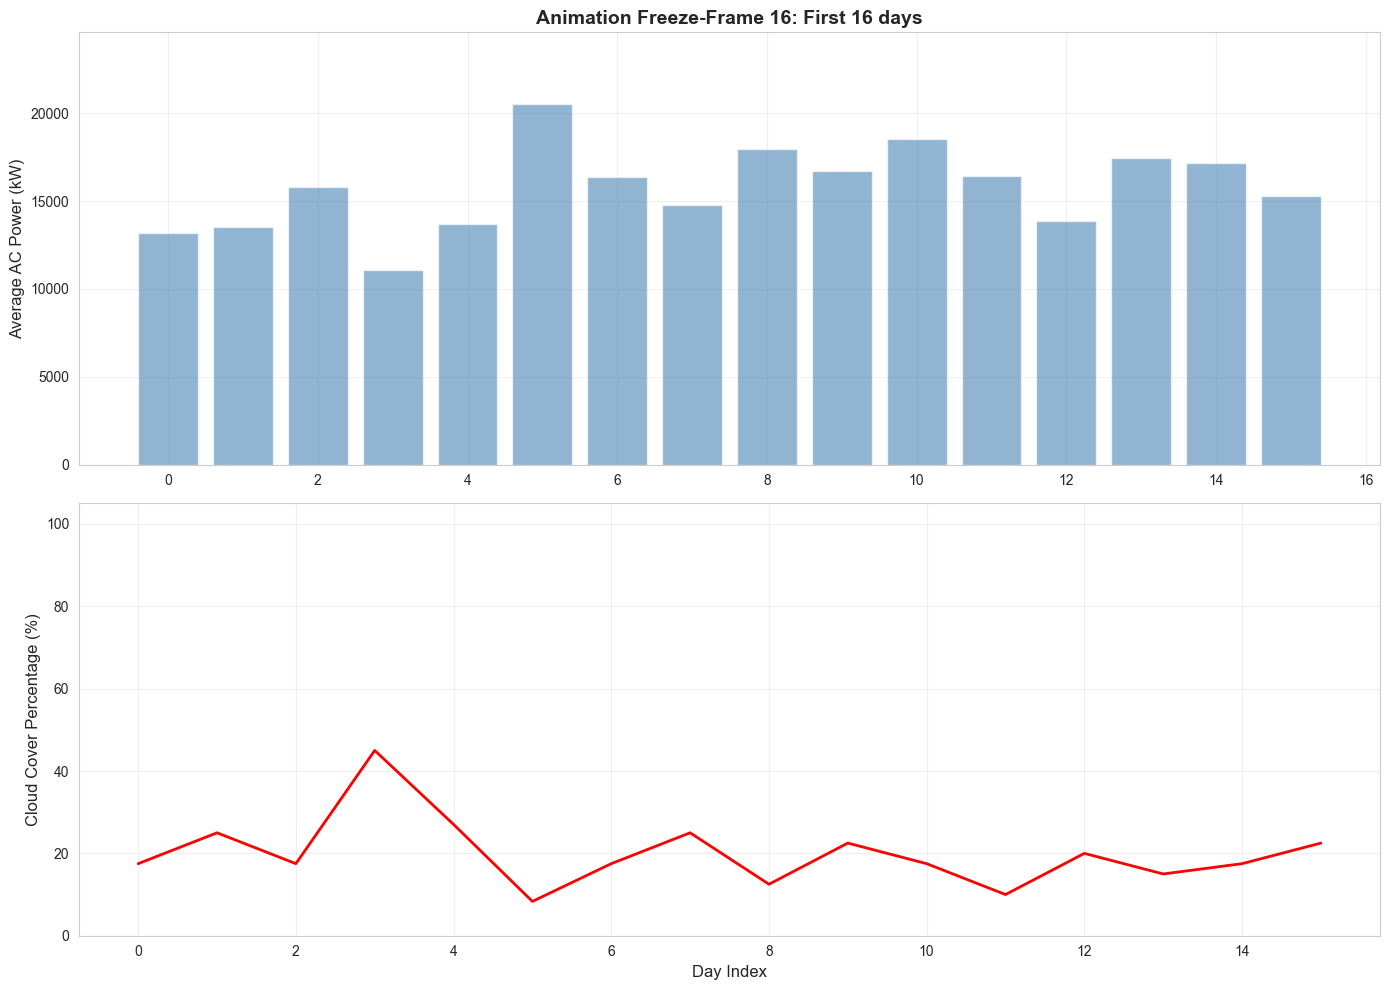

In [ ]:
# Calculate daily aggregates
df["DATE"] = pd.to_datetime(df["DATETIME"]).dt.date
daily_data = (
    df.groupby("DATE")
    .agg(
        {
            "AC_POWER": "mean",
            "IRRADIATION": "mean",
            "CLOUD_CONDITION": lambda x: (x == "Cloud-Affected").sum() / len(x) * 100,
        }
    )
    .reset_index()
)
daily_data.columns = ["DATE", "AVG_AC_POWER", "AVG_IRRADIATION", "CLOUD_PERCENT"]
daily_data = daily_data.sort_values("DATE")

# Choose freeze frame (0 = first, middle, or last)
freeze_idx = len(daily_data) - 1  # Last frame shows all days

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# TOP CHART: Blue bars ONLY (NO red line)
x_pos = range(freeze_idx + 1)
heights = daily_data.iloc[: freeze_idx + 1]["AVG_AC_POWER"].values
ax1.bar(x_pos, heights, color="steelblue", alpha=0.6)

# BOTTOM CHART: Red line ONLY (NO bars)
# This creates the red line for cloud cover percentage
ax2.plot(
    range(freeze_idx + 1),
    daily_data.iloc[: freeze_idx + 1]["CLOUD_PERCENT"].values,
    "red",
    linewidth=2,
)

# Labels and titles
ax1.set_ylabel("Average AC Power (kW)", fontsize=12)
ax2.set_ylabel("Cloud Cover Percentage (%)", fontsize=12)
ax2.set_xlabel("Day Index", fontsize=12)
ax1.set_title(
    f"Animation Freeze-Frame {freeze_idx + 1}: First {freeze_idx + 1} days",
    fontsize=14,
    fontweight="bold",
)

# Grid and limits
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
ax1.set_ylim(0, daily_data["AVG_AC_POWER"].max() * 1.2)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [39]:
print("SUMMARY STATISTICS (Cloud-Affected vs Clear-Sky)")
print("_" * 80)

print(
    "\n{:<25} {:>15} {:>15} {:>15}".format(
        "Metric", "Cloud-Affected", "Clear-Sky", "% Difference"
    )
)
print("_" * 80)

# AC Power
ac_cloud = np.mean(cloud_df["AC_POWER"].values)
ac_clear = np.mean(clear_df["AC_POWER"].values)
ac_diff = ((ac_clear - ac_cloud) / ac_clear) * 100
print(
    "{:<25} {:>15.2f} {:>15.2f} {:>14.1f}%".format(
        "AC Power (kW)", ac_cloud, ac_clear, ac_diff
    )
)

# DC Power
dc_cloud = np.mean(cloud_df["DC_POWER"].values)
dc_clear = np.mean(clear_df["DC_POWER"].values)
dc_diff = ((dc_clear - dc_cloud) / dc_clear) * 100
print(
    "{:<25} {:>15.2f} {:>15.2f} {:>14.1f}%".format(
        "DC Power (kW)", dc_cloud, dc_clear, dc_diff
    )
)

# Irradiation
irr_cloud = np.mean(cloud_df["IRRADIATION"].values)
irr_clear = np.mean(clear_df["IRRADIATION"].values)
irr_diff = ((irr_clear - irr_cloud) / irr_clear) * 100
print(
    "{:<25} {:>15.3f} {:>15.3f} {:>14.1f}%".format(
        "Irradiation (kW/m²)", irr_cloud, irr_clear, irr_diff
    )
)

# Module Temperature
temp_cloud = np.mean(cloud_df["MODULE_TEMPERATURE"].values)
temp_clear = np.mean(clear_df["MODULE_TEMPERATURE"].values)
temp_diff = temp_clear - temp_cloud
print(
    "{:<25} {:>15.1f} {:>15.1f} {:>14.1f}°C".format(
        "Module Temp (°C)", temp_cloud, temp_clear, temp_diff
    )
)

# Correlation
correlation = np.corrcoef(df["IRRADIATION"].values, df["AC_POWER"].values)[0, 1]
print("\n{:<25} {:>15.4f}".format("Correlation (Irrad vs Power)", correlation))

SUMMARY STATISTICS (Cloud-Affected vs Clear-Sky)
________________________________________________________________________________

Metric                     Cloud-Affected       Clear-Sky    % Difference
________________________________________________________________________________
AC Power (kW)                     5082.08        18359.59           72.3%
DC Power (kW)                    51841.01       187806.80           72.4%
Irradiation (kW/m²)                 0.166           0.640           74.1%
Module Temp (°C)                     33.9            49.2           15.3°C

Correlation (Irrad vs Power)          0.9917


---
<span style="font-size: 8px;">R01001100</span>